In [1]:
import pandas as pd
df = pd.read_csv('data.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [2]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  2439
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  4016
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

### Phase 2: Data Cleaning and Imputation
Looking at our dataset, we have missing values in two columns: `Item_Weight` (Numerical) and `Outlet_Size` (Categorical). We cannot simply delete these rows, or we will lose too much valuable data. 

**The Theory & Strategy:**
1. **Handling Numerical Data (Item_Weight):** Since weight is a number, we will fill the missing blanks with the **Mean (Average)** weight of all the other items. This is a standard statistical practice that keeps our data balanced.
2. **Handling Categorical Data (Outlet_Size):** Since size is a text category (Small, Medium, High), we cannot calculate an average. Instead, we will fill the blanks with the **Mode (Most Frequent Value)**. Whichever size is the most common in our dataset will be used to fill the empty spots.

In [4]:
# 1. Fill missing Item Weights with the Mean (Modern Way)
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

# 2. Fill missing Outlet Sizes with the Mode (Modern Way)
df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

# 3. Check our work to make sure it worked!
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

### Phase 3: Data Filtering
Filtering allows us to extract specific subsets of our data based on business conditions. Instead of looking at all 14,000 rows, we can isolate the data to answer specific questions. 

**Business Scenario:** Management wants to analyze the performance of stores located exclusively in **Tier 1** cities. We will create a filter to extract only those specific records.

In [5]:
# 1. Create the filter: Look inside the 'Outlet_Location_Type' column for 'Tier 1'
tier_1_data = df[df['Outlet_Location_Type'] == 'Tier 1']

# 2. Count how many rows matched our filter using the len() function
print("Total number of items sold in Tier 1 cities:", len(tier_1_data))

# 3. Show the top 3 rows of our new filtered table
tier_1_data.head(3)

Total number of items sold in Tier 1 cities: 3980


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.3,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
2,FDN15,17.5,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
10,FDY07,11.8,Low Fat,0.000000,Fruits and Vegetables,45.5402,OUT049,1999,Medium,Tier 1,Supermarket Type1,1516.0266


### Phase 4: Grouping, Aggregation, and Sorting
To understand which types of products perform the best, we cannot look at individual rows. We need to aggregate the data. 

**Business Scenario:** Management wants to know which `Item_Type` (Dairy, Meat, Snacks, etc.) generates the highest average sales across all stores. 
To answer this, we will:
1. **Group** the data by `Item_Type`.
2. **Aggregate** the data by calculating the Mean (Average) of `Item_Outlet_Sales`.
3. **Sort** the final list from highest average sales to lowest.

In [6]:
# 1. Group by Item Type and calculate the Average (Mean) Sales
grouped_sales = df.groupby('Item_Type')['Item_Outlet_Sales'].mean().reset_index()

# 2. Sort the results from Highest Sales to Lowest Sales (ascending=False means highest first)
sorted_sales = grouped_sales.sort_values(by='Item_Outlet_Sales', ascending=False)

# 3. Print the final sorted table
sorted_sales

,Item_Type,Item_Outlet_Sales
12,Seafood,2348.508294
15,Starchy Foods,2276.626228
13,Snack Foods,2186.947995
9,Household,2180.806457
6,Fruits and Vegetables,2180.256313
4,Dairy,2146.448459
1,Breads,2119.605794
3,Canned,2115.507452
10,Meat,2108.724404
2,Breakfast,2031.602837


### Phase 5: Data Visualization
Numbers in a table can be difficult to interpret quickly. Visualizing the data helps stakeholders instantly identify trends and top-performing categories.

**Action:** We will use the `matplotlib` and `seaborn` libraries to create a horizontal bar chart of our `sorted_sales` data. A horizontal chart is chosen because the `Item_Type` names are long, and they would overlap and become unreadable on a vertical axis.

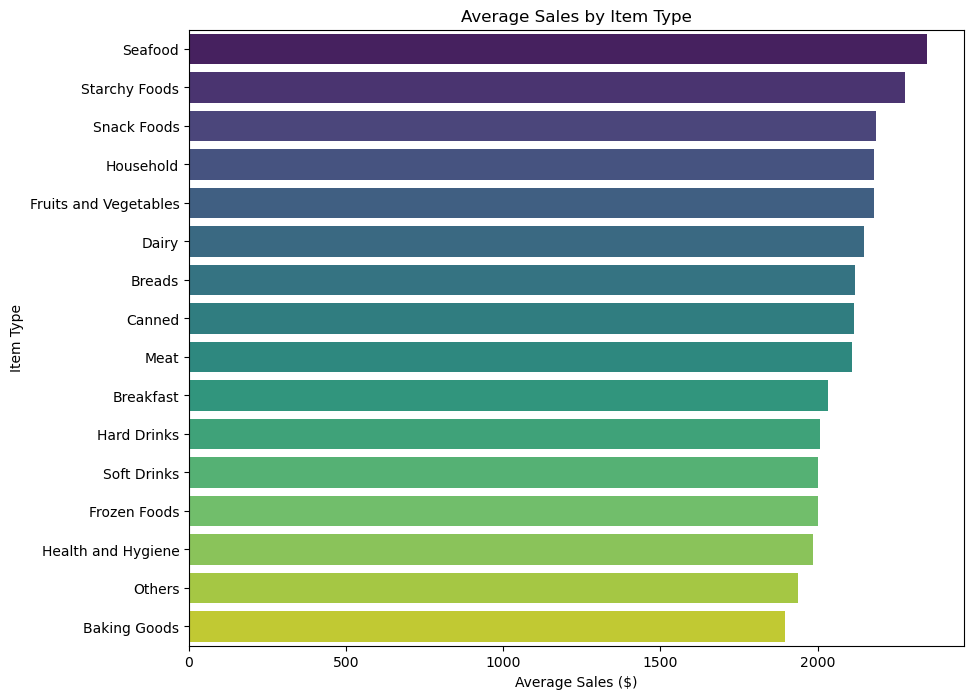

In [8]:
# 1. Import our visualization toolboxes
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Set the size of the canvas (10 inches wide, 8 inches tall)
plt.figure(figsize=(10, 8))

# 3. Create the Bar Chart using the MODERN Seaborn method
sns.barplot(x='Item_Outlet_Sales', y='Item_Type', data=sorted_sales, palette='viridis', hue='Item_Type', legend=False)

# 4. Add the titles so people know what they are looking at
plt.title('Average Sales by Item Type')
plt.xlabel('Average Sales ($)')
plt.ylabel('Item Type')

# 5. Tell Python to show the picture on the screen
plt.show()

### Phase 6: Business Queries (Batch 1 of 4)
**Theme: General Sales and Outlet Performance**
To fully understand the business, we will answer specific operational queries. In this first batch, we will use basic aggregation functions like `.sum()`, `.max()`, and `.nunique()` to find total revenue, highest single sales, and store counts.

In [9]:
print("--- BATCH 1: SALES & OUTLETS ---")

# Query 1: What is the total overall sales of the entire company?
q1 = df['Item_Outlet_Sales'].sum()
print("1. Total Company Sales: $", round(q1, 2))

# Query 2: What is the average amount a customer spends per transaction?
q2 = df['Item_Outlet_Sales'].mean()
print("2. Average Sale Amount: $", round(q2, 2))

# Query 3: What was the highest single item sale ever recorded?
q3 = df['Item_Outlet_Sales'].max()
print("3. Highest Single Sale: $", round(q3, 2))

# Query 4: How many unique supermarket outlets (stores) do we have in total?
q4 = df['Outlet_Identifier'].nunique()
print("4. Total Number of Stores:", q4)

# Query 5: Which type of outlet makes the most total money? (Grocery vs Supermarket)
q5 = df.groupby('Outlet_Type')['Item_Outlet_Sales'].sum()
print("\n5. Total Sales by Outlet Type:\n", q5)

--- BATCH 1: SALES & OUTLETS ---
1. Total Company Sales: $ 29818933.45
2. Average Sale Amount: $ 2099.33
3. Highest Single Sale: $ 13086.96
4. Total Number of Stores: 10

5. Total Sales by Outlet Type:
 Outlet_Type
Grocery Store        5.823266e+05
Supermarket Type1    2.065187e+07
Supermarket Type2    2.979587e+06
Supermarket Type3    5.605150e+06
Name: Item_Outlet_Sales, dtype: float64


### Batch 2: Time Trends and Performance Over Years
**Theme: Establishment Year Analysis**
To understand if older, more established stores outperform newer ones, we will analyze average sales based on the `Outlet_Establishment_Year`. We will visualize this using a Line Plot (Time Series) to track the trajectory of sales across different store generations.

--- BATCH 2: SALES TRENDS OVER TIME ---
Average Sales by Year:
    Outlet_Establishment_Year  Item_Outlet_Sales
0                       1985        2414.289720
1                       1987        2201.291586
2                       1997        2174.715504
3                       1998         323.269115
4                       1999        2255.243825
5                       2002        2094.341504
6                       2004        2327.254638
7                       2007        2279.676866
8                       2009        1927.288071


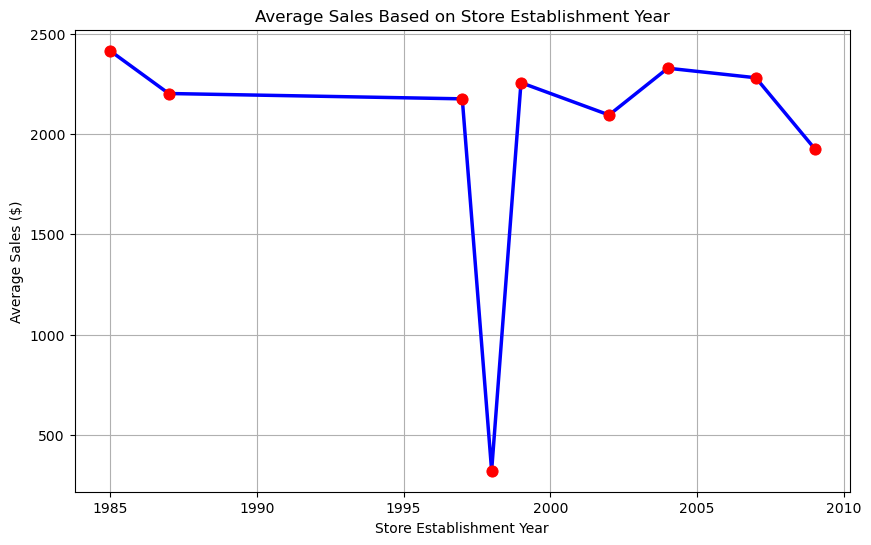

In [11]:
print("--- BATCH 2: SALES TRENDS OVER TIME ---")

# 1. Group the data to find Average Sales per Year
yearly_sales = df.groupby('Outlet_Establishment_Year')['Item_Outlet_Sales'].mean().reset_index()
print("Average Sales by Year:\n", yearly_sales)

# 2. Draw the XY Line Graph
plt.figure(figsize=(10, 6))

# 3. Create the line plot (Blue line, Red dots, slightly larger dots)
sns.lineplot(
    x='Outlet_Establishment_Year', 
    y='Item_Outlet_Sales', 
    data=yearly_sales, 
    marker='o', 
    color='blue', 
    linewidth=2.5,
    markerfacecolor='red', 
    markeredgecolor='red', 
    markersize=8
)

# 4. Add titles and a grid for a professional look
plt.title('Average Sales Based on Store Establishment Year')
plt.xlabel('Store Establishment Year')
plt.ylabel('Average Sales ($)')
plt.grid(True)

# 5. Show the graph
plt.show()

### Phase 8: Business Queries (Batch 3 of 4)
**Theme: Product Characteristics & Outlet Size Impact**
In this batch, we will dive into specific product details. First, we will clean a known data entry issue in the `Item_Fat_Content` column where "Low Fat" is inconsistently labeled as "LF" or "low fat". Then, we will analyze how Fat Content, Outlet Size, and Item Visibility impact total revenue.

In [12]:
print("--- BATCH 3: PRODUCT & OUTLET DEEP DIVE ---")

# First: Fix the messy data entry in the Fat Content column
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'})

# Query 6: Does 'Low Fat' or 'Regular' make more money overall?
q6 = df.groupby('Item_Fat_Content')['Item_Outlet_Sales'].sum()
print("6. Total Sales by Fat Content:\n", q6)

# Query 7: Do 'High' capacity stores actually make more money than 'Small' ones?
q7 = df.groupby('Outlet_Size')['Item_Outlet_Sales'].sum()
print("\n7. Total Sales by Outlet Size:\n", q7)

# Query 8: What are the exact top 3 best-selling individual items in the entire company?
q8 = df.groupby('Item_Identifier')['Item_Outlet_Sales'].sum().sort_values(ascending=False).head(3)
print("\n8. Top 3 Best-Selling Specific Items:\n", q8)

# Query 9: Is the average item price (MRP) different depending on the City Tier?
q9 = df.groupby('Outlet_Location_Type')['Item_MRP'].mean()
print("\n9. Average Item Price (MRP) by City Tier:\n", q9)

# Query 10: Data Anomaly Check - How many items have exactly 0.0 visibility on the shelves?
q10 = len(df[df['Item_Visibility'] == 0.0])
print("\n10. Items with completely 0.0 shelf visibility:", q10)

--- BATCH 3: PRODUCT & OUTLET DEEP DIVE ---
6. Total Sales by Fat Content:
 Item_Fat_Content
Low Fat    1.916660e+07
Regular    1.065233e+07
Name: Item_Outlet_Sales, dtype: float64

7. Total Sales by Outlet Size:
 Outlet_Size
High      3.418606e+06
Medium    1.913897e+07
Small     7.261356e+06
Name: Item_Outlet_Sales, dtype: float64

8. Top 3 Best-Selling Specific Items:
 Item_Identifier
FDY55    46933.227805
FDA15    45388.181511
FDK03    43306.382407
Name: Item_Outlet_Sales, dtype: float64

9. Average Item Price (MRP) by City Tier:
 Outlet_Location_Type
Tier 1    140.939480
Tier 2    140.987872
Tier 3    141.065888
Name: Item_MRP, dtype: float64

10. Items with completely 0.0 shelf visibility: 879


### Phase 9: Business Queries (Batch 4 of 4)
**Theme: Advanced Analytics and Correlation**
In our final batch, we investigate performance extremes (best/worst performing metrics) and utilize statistical correlation. Finally, we generate a **Correlation Heatmap** to visually prove which mathematical variables (like Price, Weight, or Visibility) have the strongest impact on Total Sales.

--- BATCH 4: ADVANCED ANALYTICS & CORRELATION ---
11. Total Revenue by City Tier:
 Outlet_Location_Type
Tier 1    7.149740e+06
Tier 2    1.036683e+07
Tier 3    1.230237e+07
Name: Item_Outlet_Sales, dtype: float64

12. Lowest Performing Store:
 Outlet_Identifier
OUT019    283302.695884
Name: Item_Outlet_Sales, dtype: float64

13. Correlation between Price and Sales: 0.602

14. Correlation between Visibility and Sales: -0.134

15. Generating the Correlation Heatmap...


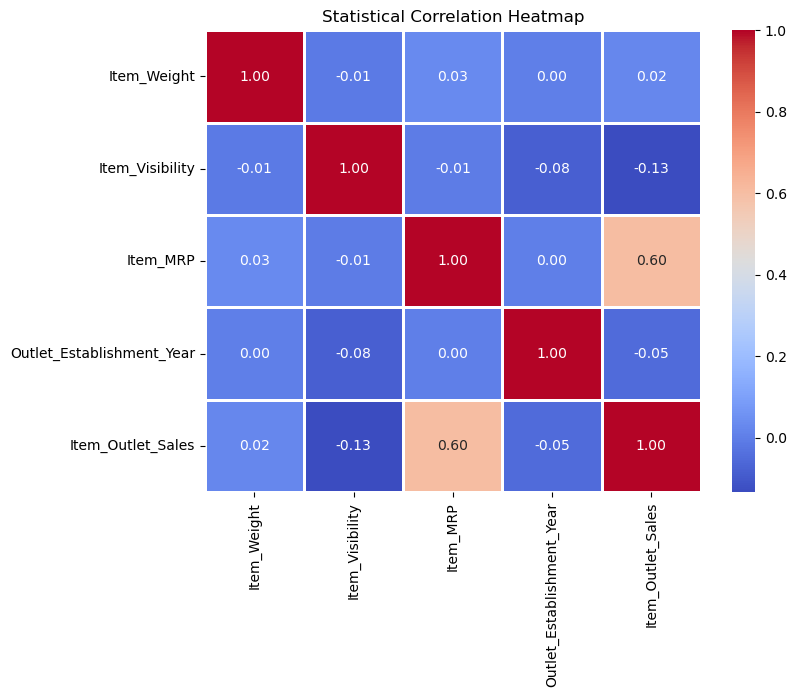

In [16]:
print("--- BATCH 4: ADVANCED ANALYTICS & CORRELATION ---")

# Query 11: Which specific city tier makes the most total revenue?
q11 = df.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].sum()
print("11. Total Revenue by City Tier:\n", q11)

# Query 12: Which specific outlet (store) is the absolute worst performing?
q12 = df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].sum().sort_values().head(1)
print("\n12. Lowest Performing Store:\n", q12)

# Query 13: Mathematical correlation between Price (MRP) and Sales
q13 = df['Item_MRP'].corr(df['Item_Outlet_Sales'])
print("\n13. Correlation between Price and Sales:", round(q13, 3))

# Query 14: Mathematical correlation between Visibility and Sales
q14 = df['Item_Visibility'].corr(df['Item_Outlet_Sales'])
print("\n14. Correlation between Visibility and Sales:", round(q14, 3))

# Query 15: The Advanced Correlation Heatmap
print("\n15. Generating the Correlation Heatmap...")
plt.figure(figsize=(8, 6))

# (We only select number columns, because we can't do math on text words like 'Dairy')
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Draw the heatmap
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)

plt.title('Statistical Correlation Heatmap')
plt.show()

### Phase 10: Business Queries (Batch 5 of 5)
**Theme: Foundational Exploration & Dataset Structure**
To complete our analysis, we formally document the structural and exploratory queries performed during the data cleaning phase. These queries define the exact dimensions of our dataset, verify our filtering conditions (like Tier 1 cities), and map the distribution of our supermarket network.

In [18]:
print("--- BATCH 5: FOUNDATION & EXPLORATION ---")

# Query 16: What is the exact size of our dataset (Rows and Columns)?
q16_rows, q16_cols = df.shape
print(f"16. Dataset Size: {q16_rows} Rows and {q16_cols} Columns")

# Query 17: How many unique types of items do we sell across the company?
q17 = df['Item_Type'].nunique()
print("\n17. Total Unique Item Categories:", q17)

# Query 18: What is the exact number of items sold exclusively in Tier 1 cities?
q18 = len(df[df['Outlet_Location_Type'] == 'Tier 1'])
print("\n18. Total Items Sold in Tier 1 Cities:", q18)

# Query 19: What is the distribution of our Outlet Sizes? (How many Medium, Small, High?)
q19 = df['Outlet_Size'].value_counts()
print("\n19. Outlet Size Distribution:\n", q19)

# Query 20: Which single Item Category has the highest average sales?
q20 = df.groupby('Item_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False).head(1)
print("\n20. Highest Selling Category (Average):\n", q20)

print("\n*** ALL 20 BUSINESS QUERIES SUCCESSFULLY COMPLETED! ***")

--- BATCH 5: FOUNDATION & EXPLORATION ---
16. Dataset Size: 14204 Rows and 12 Columns

17. Total Unique Item Categories: 16

18. Total Items Sold in Tier 1 Cities: 3980

19. Outlet Size Distribution:
 Outlet_Size
Medium    8671
Small     3980
High      1553
Name: count, dtype: int64

20. Highest Selling Category (Average):
 Item_Type
Seafood    2348.508294
Name: Item_Outlet_Sales, dtype: float64

*** ALL 20 BUSINESS QUERIES SUCCESSFULLY COMPLETED! ***


### Phase 11: Executive Summary & Conclusion
**Theme: Overall Revenue Composition**
To conclude our analysis, we will visualize the overall distribution of our total revenue. By mapping the sales contribution of each `Outlet_Type` into a composition pie chart, we can instantly identify our primary business drivers (majority influence) versus our supplementary revenue streams (minor influence).

--- FINAL SUMMARY: REVENUE COMPOSITION ---


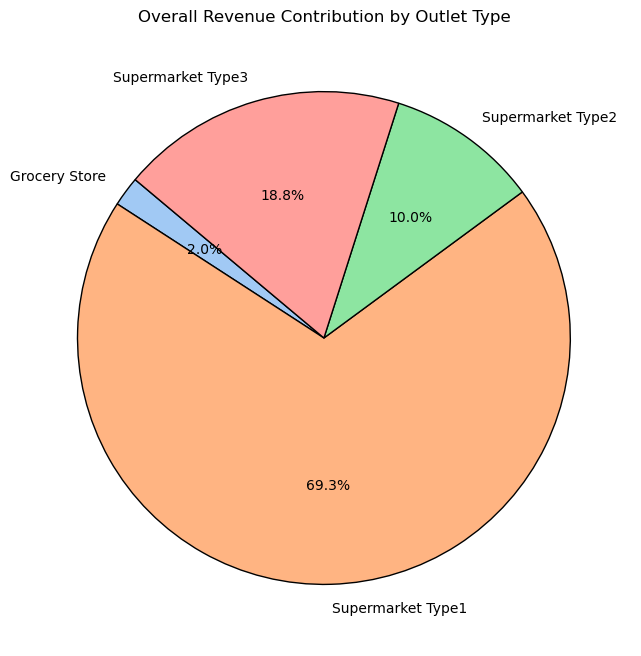

In [14]:
print("--- FINAL SUMMARY: REVENUE COMPOSITION ---")

# 1. Group the total sales by Outlet Type
sales_by_outlet = df.groupby('Outlet_Type')['Item_Outlet_Sales'].sum()

# 2. Set up the canvas
plt.figure(figsize=(8, 8))

# 3. Create the pie chart with automatic percentages
# autopct='%1.1f%%' tells Python to calculate the percentages and print them on the slices
# wedgeprops adds a nice black border around the slices so it looks clean
plt.pie(
    sales_by_outlet, 
    labels=sales_by_outlet.index, 
    autopct='%1.1f%%', 
    colors=sns.color_palette('pastel'), 
    startangle=140, 
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)

# 4. Add the final title
plt.title('Overall Revenue Contribution by Outlet Type')

# 5. Show the chart
plt.show()

### Phase 12: Visualizing the Product Drivers (The Grand Finale)
**Theme: Internal Product Impact on Sales**
While our heatmap provided the mathematical correlation coefficients, we must visually prove these findings. We will use scatter plots with regression trendlines to map every single product. This will visually confirm that Item Price (MRP) has a steep positive impact, Item Weight has a flat/neutral impact, and Item Visibility has a slight negative trajectory.

### Machine Learning Concept Integration: Linear Regression
To scientifically validate our findings, we are utilizing **Linear Regression**, a foundational supervised machine learning algorithm. 

**The Theory:**
Linear Regression attempts to model the relationship between two variables by fitting a linear equation (a straight line) to observed data. The algorithm calculates the "Line of Best Fit" by minimizing the distance between the line itself and all the individual data points (a process called Ordinary Least Squares).

**Application in Our Project:**
Instead of just eyeballing the scatter plots, we are deploying a regression algorithm (`sns.regplot`) to draw the mathematical trendline. 
* A line sloping up proves a positive coefficient (Price drives Sales).
* A flat line proves a near-zero coefficient (Weight is irrelevant).
* A line sloping down proves a negative coefficient (Visibility hurts Sales).

--- FINAL PROOF: INTERNAL PRODUCT DRIVERS ---


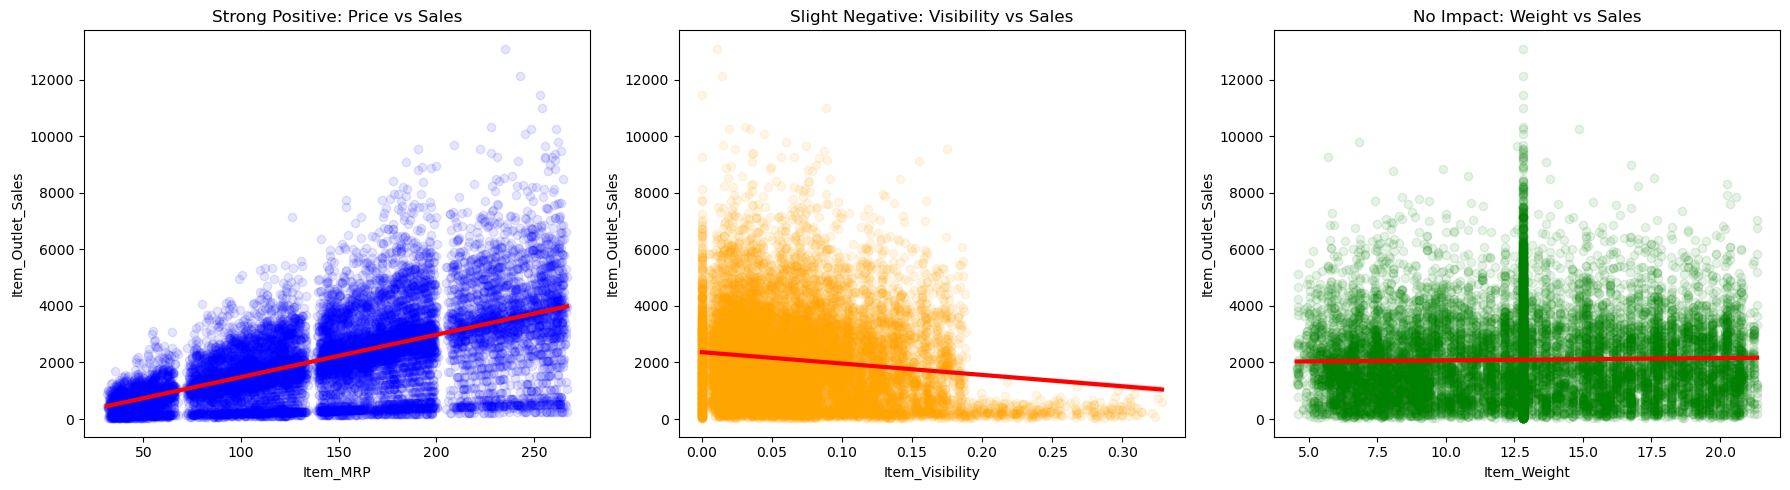

In [15]:
print("--- FINAL PROOF: INTERNAL PRODUCT DRIVERS ---")

# 1. Set up a wide canvas to hold 3 charts side-by-side
plt.figure(figsize=(18, 5))

# 2. Chart 1: Price vs Sales (The Strong Driver)
plt.subplot(1, 3, 1)
sns.regplot(x='Item_MRP', y='Item_Outlet_Sales', data=df, scatter_kws={'alpha':0.1, 'color':'blue'}, line_kws={'color':'red', 'linewidth':3})
plt.title('Strong Positive: Price vs Sales')

# 3. Chart 2: Visibility vs Sales (The Anomaly)
plt.subplot(1, 3, 2)
sns.regplot(x='Item_Visibility', y='Item_Outlet_Sales', data=df, scatter_kws={'alpha':0.1, 'color':'orange'}, line_kws={'color':'red', 'linewidth':3})
plt.title('Slight Negative: Visibility vs Sales')

# 4. Chart 3: Weight vs Sales (The Useless Data)
plt.subplot(1, 3, 3)
sns.regplot(x='Item_Weight', y='Item_Outlet_Sales', data=df, scatter_kws={'alpha':0.1, 'color':'green'}, line_kws={'color':'red', 'linewidth':3})
plt.title('No Impact: Weight vs Sales')

# 5. Make it look neat and show it
plt.tight_layout()
plt.show()